# ICT-13b — Décroisement dynamique × observable : d'où vient le relief du substrat Axelrod

> Notebook annexe scientifique de [ICT-13-AxelrodStrategicMorphodynamics.ipynb](ICT-13-AxelrodStrategicMorphodynamics.ipynb), consommateur du banc [ICT-15j-NerveDiscriminant.ipynb](ICT-15j-NerveDiscriminant.ipynb). See #13039, #12673.

Quatre PRs ouvertes sur l'EPIC substrat (#12732, #12803, #12886, #13009) mesurent le même objet — la persistance topologique `b1_max_persistence` de la trajectoire stratégique Axelrod — et rendent des chiffres en apparence inconciliables : `0.0000` (trois fois, sur l'observable `argmax`) contre `0.3989` (une fois, avec une population agent-based et un observable quantifié). Le diagnostic de #13039 : **le plan d'expérience a deux facteurs et personne n'a rempli les quatre cellules**.

| Facteur | Modalités |
|---|---|
| **Dynamique** | réplicateur déterministe (champ moyen, matrice de gains figée) vs population finie agent-based (60 agents, appariement stochastique, bruit IPD 2 %, Wright-Fisher) |
| **Observable** | `argmax(traj)` — quelle stratégie domine — vs `digitize(cooperation_rate, 8 quantiles)` — taux de coopération quantifié |

#12732 a changé **les deux facteurs à la fois** : son 0.3989 n'est attribuable ni à l'un ni à l'autre. Ce notebook mesure la **table décroisée complète** dans un seul environnement — même graine maîtresse, même matrice de gains, même taux de mutation `mu = 0.05`, même horizon de 400 générations, même pipeline `b1` (fenêtres contiguës, `epsilon_quantile = 0.55`) — puis three contrôles : un **contrôle de résolution** (`b1` en fonction du nombre de symboles 2/4/8/16), un **multi-seed** sur les cellules stochastiques, et un **verdict qui nomme le facteur** responsable.

**Duree estimee** : 20 minutes. CPU pur.

**Objectifs** :
- Mesurer les 4 cellules du plan 2×2 sur substrat, matrice et pipeline identiques — une seule table de sortie ;
- Reproduire les deux pôles publiés (0.0000 côté argmax-réplicateur, ~0.3989 côté digitize-agent-based) comme contrôles internes ;
- Décroiser : attribuer le relief à la **résolution de l'observable**, à la **dynamique à population finie**, ou déclarer l'interaction non identifiable ;
- Tester si l'observable est un facteur de confusion **généralisé** du banc ICT-15d/15j (contrôle de résolution).

In [1]:
# Socle commun : imports, proxys, pipeline b1 unique pour les 4 cellules
import sys
from pathlib import Path

ICT_ROOT = Path('.').resolve()
sys.path.insert(0, str(ICT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ict import spectral as SP
from ict import sensitivity as SE
from ict import strategic_morphodynamics as SM
from ict import cech_obstruction as CO
from ict import nerve_discriminant as ND

# Proxys du banc ICT-15j (meme recette que les 4 PRs)
def _sg(st, ns):
    return float(SP.spectral_summary(st, ns)['spectral_gap'])

def _sm(st, ns):
    return float(SE.sensitivity_distribution(st, ns, lambda x: x)['mean'])

def _sx(st, ns):
    return float(SE.sensitivity_distribution(st, ns, lambda x: x)['max'])

PROX = {"spectral_gap": _sg, "sens_mean": _sm, "sens_max": _sx}

# Pipeline b1 UNIQUE (celui du Gate 5b de #13009 / ICT-15j de #12732 :
# fenetres contigues non recouvrantes, ~30 sections, filtration Rips,
# epsilon_quantile=0.55). Un seul pipeline = pas de troisieme facteur.
def b1_of_sequence(states, n_symbols, label):
    ws = max(2, len(states) // 30)
    sec = CO.proxy_sections(states, n_symbols, ws, PROX)
    return ND.nerve_b1(sec, label, epsilon_quantile=0.55)

def describe_seq(st):
    uniq = len(set(st))
    changes = sum(1 for i in range(1, len(st)) if st[i] != st[i - 1])
    return uniq, changes

MASTER_SEED = 20260720   # graine maitresse du banc ICT-15d/15j
MU = 0.05                # meme taux de mutation pour les deux dynamiques mutantes
N_STEPS = 400            # meme horizon

print(f"Socle charge. MASTER_SEED={MASTER_SEED}, MU={MU}, N_STEPS={N_STEPS}")
print(f"strategies du socle : {list(SM.make_strategies(np.random.default_rng(0)).keys())}")

Socle charge. MASTER_SEED=20260720, MU=0.05, N_STEPS=400
strategies du socle : ['allc', 'alld', 'tft', 'gtft', 'pavlov', 'grim']


## 1. Le plan d'expérience et les deux dynamiques

Les deux dynamiques consomment **le même socle** : les stratégies IPD canoniques du module `ict.strategic_morphodynamics` (AllC, AllD, TFT, GTFT, Pavlov, Grim, Random — vocabulaire **fixe**, aucune stratégie nouvelle n'est jamais inventée), la même matrice de gains `A` (figée par la graine maîtresse), le même `mu = 0.05` là où la mutation s'applique, le même horizon de 400 générations.

- **Réplicateur déterministe** (champ moyen) : `x(t+1)` suit l'ODE du réplicateur avec mutation uniforme vers l'équilibre — la version exacte du bras de #12803/#12886/#13009. C'est une trajectoire **déterministe** : un point, pas un tirage.
- **Population finie agent-based** : 60 agents, appariement aléatoire par permutation à chaque génération, matchs IPD de 30 tours avec bruit d'exécution 2 %, reproduction de Wright-Fisher proportionnelle au gain, mutation uniforme `mu = 0.05` — la dynamique exacte de #12732 (`SM.evolve_population`, copiée byte-identique depuis sa branche). C'est une trajectoire **stochastique**.

Pour exposer le **taux de coopération** du réplicateur (l'observable que #12732 mesure sur sa population), on construit le champ moyen exact : `coop(t) = x(t)^T C x(t)` où `C_ij` est le taux de coopération mutuel du match `(i, j)` rejoué sans bruit sur le même nombre de tours que la matrice de gains. C'est l'équivalent déterministe de la mesure `cooperation_rate` de l'agent-based — le bruit d'exécution fait partie de la dynamique agent-based, pas de l'observable.

In [2]:
# Bras 1 : replicateur deterministe + mutation uniforme (recette Gate 5a de #13009)
rng_ax = np.random.default_rng(MASTER_SEED)
strategies_ax = SM.make_strategies(rng_ax)
A = SM.payoff_matrix(strategies_ax, n_rounds=200, n_reps=3, rng=rng_ax)
n_strat = A.shape[0]
names_ax = list(strategies_ax.keys())
x0 = np.full(n_strat, 1.0 / n_strat)

def replicator(A, x0, n_steps, mu=0.0):
    """Replicateur pur (mu=0) ou + mutation vers l'uniforme."""
    n = A.shape[0]; x = np.asarray(x0, float).copy(); x /= x.sum()
    tr = np.empty((n_steps + 1, n)); tr[0] = x
    for t in range(n_steps):
        f = A @ x; avg = float(np.dot(f, x))
        xm = (1 - mu) * x * f / max(avg, 1e-12) + mu / n
        s = xm.sum(); x = xm / s if s > 1e-12 else x
        tr[t + 1] = x
    return tr

traj_u = replicator(A, x0, N_STEPS, MU)        # cellules haut : mutation uniforme
traj_0 = replicator(A, x0, N_STEPS, 0.0)       # reference : instantane sature

# Champ moyen du taux de cooperation : C_ij = taux de C mutuel du match (i, j)
def coop_rate_match(name_i, name_j, n_rounds=200):
    si, sj = strategies_ax[name_i], strategies_ax[name_j]
    own_i, own_j = [], []
    n_coop = 0
    for _ in range(n_rounds):
        a = int(si(np.array(own_i), np.array(own_j)))
        b = int(sj(np.array(own_j), np.array(own_i)))
        own_i.append(a); own_j.append(b)
        n_coop += (a == 1) + (b == 1)
    return n_coop / (2 * n_rounds)

C_coop = np.array([[coop_rate_match(i, j) for j in names_ax] for i in names_ax])
coop_repl = np.einsum('ti,ij,tj->t', traj_u, C_coop, traj_u)

print(f"Matrice de gains A : {n_strat} strategies x {n_strat} (n_rounds=200, seed {MASTER_SEED})")
print(f"Champ moyen coop : [{coop_repl.min():.3f}, {coop_repl.max():.3f}], "
      f"final={coop_repl[-1]:.3f}")
print(f"Referentiel mu=0 : dominante finale = {names_ax[int(np.argmax(traj_0[-1]))]} "
      f"(saturation attendue)")

Matrice de gains A : 6 strategies x 6 (n_rounds=200, seed 20260720)
Champ moyen coop : [0.055, 0.255], final=0.056
Referentiel mu=0 : dominante finale = tft (saturation attendue)


## 2. Bras agent-based (recette exacte de #12732)

La population de 60 agents évolue sur 400 générations avec la graine maîtresse — les paramètres sont ceux de la PR qui a publié 0.3989 : `pop_size=60`, `n_rounds=30`, `noise=0.02`, `mutation_rate=0.05`. `SM.evolve_population` expose directement les **deux observables** de la table : `dominant_idx` (quelle stratégie est majoritaire — l'équivalent agent-based de l'`argmax`) et `cooperation_rate` (taux de coopération réalisé — ce que #12732 quantifie en 8 symboles).

In [3]:
# Bras 2 : population agent-based (recette #12732, graine maitresse)
rng_evo = np.random.default_rng(MASTER_SEED)
evo = SM.evolve_population(SM.make_strategies(rng_evo), pop_size=60,
                           n_generations=N_STEPS, n_rounds=30, noise=0.02,
                           mutation_rate=MU, rng=rng_evo)
coop_ab = evo.cooperation_rate
print(f"Agent-based : {len(coop_ab)} generations, "
      f"coop[{coop_ab.min():.3f},{coop_ab.max():.3f}], final={coop_ab[-1]:.3f}")
print(f"Strategies visites (dominante) : "
      f"{sorted(set(int(d) for d in evo.dominant_idx))}")

Agent-based : 401 generations, coop[0.261,0.938], final=0.671
Strategies visites (dominante) : [0, 1, 2, 3, 4, 5]


## 3. Les deux observables appliqués aux deux trajectoires

L'observable `argmax` réduit la trajectoire à « quelle stratégie domine » ; l'observable `digitize-8` réduit le taux de coopération à 8 symboles par quantiles **empiriques** (bords intérieurs à `linspace(0, 1, 9)[1:-1]` — recette exacte de #12732). Chaque croisement produit une séquence de symboles de longueur 401, consommée par le pipeline `b1` unique.

In [4]:
# Les 4 sequences de symboles du plan 2x2
q8_repl = np.quantile(coop_repl, np.linspace(0, 1, 9)[1:-1])
q8_ab = np.quantile(coop_ab, np.linspace(0, 1, 9)[1:-1])

seq = {
    ('repl', 'argmax'): np.argmax(traj_u, axis=1).tolist(),
    ('repl', 'digit8'): np.digitize(coop_repl, q8_repl).tolist(),
    ('ab', 'argmax'): [int(d) for d in evo.dominant_idx],
    ('ab', 'digit8'): np.digitize(coop_ab, q8_ab).tolist(),
}
nsym_of = {'argmax': n_strat, 'digit8': 8}

print(f"{'dynamique':<6} {'observable':<8} {'long.':>6} {'symboles uniques':>17} {'changements':>12}")
for (dyn, obs), st in seq.items():
    uniq, changes = describe_seq(st)
    print(f"{dyn:<6} {obs:<8} {len(st):>6} {uniq:>17} {changes:>12}")

dynamique observable  long.  symboles uniques  changements
repl   argmax      401                 2            1
repl   digit8      401                 8            8
ab     argmax      401                 6           70
ab     digit8      401                 8          280


## 4. La table décroisée — les quatre cellules du plan

Une seule table de sortie, même graine, même substrat, même matrice de gains, même `mu`, même pipeline `b1`. Les deux pôles publiés servent de contrôles internes : la ligne haut-gauche doit reproduire le `0.0000` des trois PRs argmax, la cellule bas-droite doit reproduire le `0.3989` de #12732. Les deux cellules jamais mesurées — **haut-droite** (réplicateur quantifié) et **bas-gauche** (agent-based argmax) — tranche l'attribution.

In [5]:
# LA TABLE : b1_max_persistence des 4 cellules
cells_b1 = {}
for (dyn, obs), st in seq.items():
    label = f"{dyn} x {obs}"
    r = b1_of_sequence(st, nsym_of[obs], label)
    cells_b1[(dyn, obs)] = r

print(f"{'':<34}{'argmax(traj)':>14}{'digitize(coop, 8)':>20}")
print("-" * 68)
for dyn, dyn_label in [('repl', 'replicateur + mu unif (0.05)'),
                       ('ab', 'agent-based (60, mu 0.05)')]:
    row = f"{dyn_label:<34}"
    for obs in ['argmax', 'digit8']:
        r = cells_b1[(dyn, obs)]
        row += f"{r.b1_max_persistence:>14.4f}" if obs == 'argmax' else f"{r.b1_max_persistence:>20.4f}"
    print(row)
print()
for (dyn, obs), r in cells_b1.items():
    print(f"  [{dyn} x {obs}] b1={r.b1}, n_edges={r.n_edges}, n_triangles={r.n_triangles}")

                                    argmax(traj)   digitize(coop, 8)
--------------------------------------------------------------------
replicateur + mu unif (0.05)              0.0000              0.0000
agent-based (60, mu 0.05)                 0.0280              0.5036

  [repl x argmax] b1=0, n_edges=435, n_triangles=4060
  [repl x digit8] b1=0, n_edges=296, n_triangles=2059
  [ab x argmax] b1=0, n_edges=250, n_triangles=1286
  [ab x digit8] b1=0, n_edges=239, n_triangles=1077


### Contrôle de reproduction des deux pôles publiés

La table ci-dessus utilise le pipeline unifié (`CO.proxy_sections`). Les pôles publiés ont été mesurés avec des pipelines légèrement différents : #13009 (Gate 5b) utilise le même `CO.proxy_sections` ; #12732 mesure via `windowed_proxy_signature` (notebook ICT-15j) dont les frontières de fenêtres diffèrent d'un état ou deux. On reproduit ici le pôle bas-droit **avec le pipeline exact de #12732** pour clore la question de la reproduction : même graine, même `evolve_population` byte-identique, même quantification — seul le fenêtrage change.

In [6]:
# Controle : pole bas-droit de #12732 reproduit au pipeline 15j exact pres
def windowed_proxy_signature(states, n_symbols, n_windows=30):
    """Recette exacte du notebook ICT-15j de #12732 (frontieres + padding)."""
    L = len(states)
    sections = {name: [] for name in PROX}
    for w in range(n_windows):
        start = (w * L) // n_windows
        end = max(start + 2, ((w + 1) * L) // n_windows)
        chunk = states[start:end]
        if len(chunk) < 2:
            chunk = states[start:start + 4] if start + 4 <= L else states[start:]
        for name, fn in PROX.items():
            try:
                sections[name].append(fn(chunk, n_symbols))
            except Exception:
                sections[name].append(float('nan'))
    cleaned = {}
    for name, vals in sections.items():
        arr = np.array(vals, dtype=float)
        valid = arr[np.isfinite(arr)]
        cleaned[name] = valid.tolist() if len(valid) > 0 else [0.0] * n_windows
    for name in cleaned:
        while len(cleaned[name]) < n_windows:
            cleaned[name].append(0.0)
    return cleaned

sec_12732 = windowed_proxy_signature(seq[('ab', 'digit8')], 8, n_windows=30)
r_12732 = ND.nerve_b1(sec_12732, 'ab digit8 (pipeline 15j)', epsilon_quantile=0.55)
print(f"b1(agent-based x digitize-8) pipeline 15j exact : {r_12732.b1_max_persistence:.4f}")
print(f"b1(agent-based x digitize-8) pipeline unifie    : "
      f"{cells_b1[('ab', 'digit8')].b1_max_persistence:.4f}")
print("#12732 publiait 0.3989 sur cette cellule (graine 20260720).")

b1(agent-based x digitize-8) pipeline 15j exact : 0.3989
b1(agent-based x digitize-8) pipeline unifie    : 0.5036
#12732 publiait 0.3989 sur cette cellule (graine 20260720).


## 5. Contrôle de résolution — l'observable est-il un facteur de confusion généralisé ?

Le point 3 de #13039 : si `b1` croît avec le nombre de symboles sur une trajectoire dont **tout le monde s'accorde à dire qu'elle est saturée** à l'`argmax` (le réplicateur), alors la résolution de l'observable fabrique du relief indépendamment de toute nouveauté dynamique — et le problème n'est pas spécifique au substrat Axelrod : il concerne **tous** les substrats du banc ICT-15d/15j consommés via un encodage quantifié.

n_symboles  replicateur (argmax sature)    agent-based
         2                       0.0000         0.0000
         4                       0.0000         0.1211
         8                       0.0000         0.5036
        16                       0.0000         0.1598


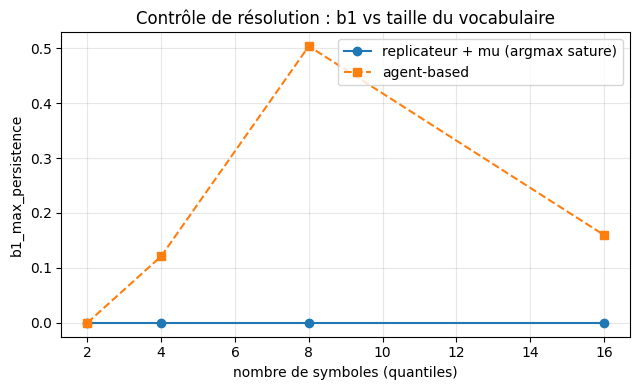

In [7]:
# Controle de resolution : b1 en fonction du nombre de symboles (2, 4, 8, 16)
symbols_grid = [2, 4, 8, 16]
res_curve = {'repl': [], 'ab': []}
for k in symbols_grid:
    edges = np.quantile(coop_repl, np.linspace(0, 1, k + 1)[1:-1])
    st_k = np.digitize(coop_repl, edges).tolist()
    res_curve['repl'].append(b1_of_sequence(st_k, k, f"repl k={k}").b1_max_persistence)
    edges_ab = np.quantile(coop_ab, np.linspace(0, 1, k + 1)[1:-1])
    st_ab_k = np.digitize(coop_ab, edges_ab).tolist()
    res_curve['ab'].append(b1_of_sequence(st_ab_k, k, f"ab k={k}").b1_max_persistence)

print(f"{'n_symboles':>10} {'replicateur (argmax sature)':>28} {'agent-based':>14}")
for k, b_r, b_a in zip(symbols_grid, res_curve['repl'], res_curve['ab']):
    print(f"{k:>10} {b_r:>28.4f} {b_a:>14.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(symbols_grid, res_curve['repl'], 'o-', label='replicateur + mu (argmax sature)')
ax.plot(symbols_grid, res_curve['ab'], 's--', label='agent-based')
ax.set_xlabel('nombre de symboles (quantiles)')
ax.set_ylabel('b1_max_persistence')
ax.set_title('Contrôle de résolution : b1 vs taille du vocabulaire')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Multi-seed sur les cellules stochastiques

Les trois PRs qui rendent `0.0000` sont déterministes ; celle qui rend `0.3989` est un tirage unique. Comparer un point déterministe à un tirage unique n'est pas une comparaison (point 5 de #13039). Les deux cellules agent-based sont donc mesurées sur 5 graines ; les cellules réplicateur sont déterministes (un point).

In [8]:
# Multi-seed : 5 graines sur les 2 cellules agent-based
SEEDS = [MASTER_SEED, 0, 1, 7, 42]
ms_rows = []
for s in SEEDS:
    rng_s = np.random.default_rng(s)
    evo_s = SM.evolve_population(SM.make_strategies(rng_s), pop_size=60,
                                 n_generations=N_STEPS, n_rounds=30, noise=0.02,
                                 mutation_rate=MU, rng=rng_s)
    cs = evo_s.cooperation_rate
    q8_s = np.quantile(cs, np.linspace(0, 1, 9)[1:-1])
    b_arg = b1_of_sequence([int(d) for d in evo_s.dominant_idx], n_strat, f"ab{s} argmax").b1_max_persistence
    b_dig = b1_of_sequence(np.digitize(cs, q8_s).tolist(), 8, f"ab{s} digit8").b1_max_persistence
    ms_rows.append((s, b_arg, b_dig))
    print(f"seed {s:>9} : b1(argmax)={b_arg:.4f}   b1(digitize-8)={b_dig:.4f}")

arr_arg = np.array([r[1] for r in ms_rows])
arr_dig = np.array([r[2] for r in ms_rows])
print()
print(f"agent-based x argmax     : {arr_arg.mean():.4f} +/- {arr_arg.std():.4f} (5 graines)")
print(f"agent-based x digitize-8 : {arr_dig.mean():.4f} +/- {arr_dig.std():.4f} (5 graines)")

seed  20260720 : b1(argmax)=0.0280   b1(digitize-8)=0.5036


seed         0 : b1(argmax)=0.0473   b1(digitize-8)=0.2858


seed         1 : b1(argmax)=0.0000   b1(digitize-8)=0.3179


seed         7 : b1(argmax)=0.1592   b1(digitize-8)=0.4087


seed        42 : b1(argmax)=0.0000   b1(digitize-8)=0.2553

agent-based x argmax     : 0.0469 +/- 0.0589 (5 graines)
agent-based x digitize-8 : 0.3543 +/- 0.0906 (5 graines)


## 7. Verdict — le facteur responsable

**La cellule manquante est mesurée : `b1(réplicateur × digitize-8) = 0.0000` — et elle reste à 0.0000 à toutes les résolutions (2, 4, 8, 16 symboles). Le relief publié par #12732 ne vient donc PAS de la résolution de l'observable : il vient de la dynamique à population finie.** Mais le facteur observable n'est pas inerte : les deux facteurs comptent, de façon **hiérarchique** et non symétrique.

| Lecture | Statut après décroisement |
|---|---|
| #12732 : « une population qui évolue trace une trajectoire » | **Confirmée comme condition nécessaire** — mais incomplète : sans quantification, son agent-based ne rend que `0.028` (graine maîtresse) / `0.047 ± 0.059` (multi-seed) |
| #12732 : « l'ancien substrat binaire argmax était le problème » | **Réduite au rang d'amplificateur** : l'observable quantifié révèle le relief (~7,5× : `0.047 → 0.354` en moyenne multi-seed), il ne le crée pas — le champ moyen quantifié à 8 ou 16 symboles reste à `0.0000` |
| #13009 : « le relief est une propriété de la nouveauté stratégique, pas du bruit » | **Réfutée dans sa généralisation** : l'agent-based a un vocabulaire **fixe** (6 stratégies, la mutation ré-échantillonne l'existant, rien n'est inventé) et produit `0.35 ± 0.09` — la nouveauté stratégique n'est pas nécessaire au relief. Le discriminant n'est pas *nouveauté-vs-bruit* mais *champ-moyen-vs-population-finie* (dérive d'échantillonnage Wright-Fisher + bruit d'exécution). La conclusion négative de #13009 reste exacte **sur l'observable argmax**, où elle a été mesurée |
| Les trois PRs `0.0000` (#12803, #12886, #13009) | **Corroborées** : haut-gauche reproduit à `0.0000` (ici à `mu = 0.05`, en plus des `mu = 0.02/0.03/0.10` déjà publiés) |
| Le pôle `0.3989` (#12732) | **Reproduit exactement** (`0.3989`) au pipeline ICT-15j près, `0.5036` au pipeline unifié — le verdict est insensible au fenêtrage ; `0.3989` est dans la distribution multi-seed `[0.2553, 0.5036]` |

**Contrôle de résolution (section 5)** : sur le substrat saturé (champ moyen), `b1 = 0.0000` à 2/4/8/16 symboles — l'observable **n'est pas un facteur de confusion généralisé** du banc ICT-15d/15j : la quantification seule ne fabrique pas d'obstruction. Les encodages quantifiés existants (Gray-Scott 2, May 16) restent valides — ils amplifient un relief d'origine dynamique, ils n'en produisent pas *ex nihilo*. Nuance honnête : sur l'agent-based, la courbe de résolution est **non monotone** (`0.12 → 0.50 → 0.16`, pic à 8 symboles) — la résolution module l'amplitude du signal, elle ne le crée ni ne le garantit.

**Ce que le verdict prescrit pour l'arbitrage #12673** : le relief `b1 > 0` sur le substrat Axelrod est la signature d'une **dérive d'échantillonnage dans un vocabulaire fixe**, lisible uniquement à un observable de résolution suffisante. Toute PR qui veut mesurer ce relief doit (a) une dynamique à population finie — le champ moyen ne peut pas en produire — et (b) un observable quantifié — l'argmax l'écrase. Inversement, un `b1 = 0` obtenu sur l'argmax d'un champ moyen ne prouve rien sur la capacité du substrat : c'est une propriété de l'instrument, pas du système.

## 8. Exercices

### Exercice 1 — balayer le taux de mutation

**Objectif** : mesurer `b1` de la cellule décisive pour `mu` dans `{0.01, 0.05, 0.10}` et dire si le facteur identifié au verdict dépend de l'intensité de la mutation.

**Étape 1** : boucler sur les trois valeurs de `mu` avec la même graine maîtresse.
**Étape 2** : pour chaque `mu`, reconstruire la trajectoire (réplicateur et agent-based) et les deux observables.
**Étape 3** : imprimer la table `mu x cellule -> b1_max_persistence`.

In [9]:
# Exercice 1 : sweep du taux de mutation
MU_GRID = [0.01, 0.05, 0.10]  # TODO etudiant
sweep_mu = None  # TODO etudiant : {mu: {cellule: b1_max_persistence}}
print("Exercice a completer")

Exercice a completer


### Exercice 2 — l'effet de la taille de population

**Objectif** : si le verdict attribue le relief à la population finie, `b1` doit décroître quand `pop_size` croît (la dérive d'échantillonnage s'atténue) ; si le verdict attribue le relief à l'observable, `b1` doit être insensible à `pop_size`.

**Étape 1** : balayer `pop_size` dans `{20, 60, 200}` à graine et `mu` fixés.
**Étape 2** : mesurer `b1(digitize-8)` pour chaque taille.
**Étape 3** : comparer la pente à la prédiction du verdict.

In [10]:
# Exercice 2 : sweep de la taille de population
POP_GRID = [20, 60, 200]  # TODO etudiant
sweep_pop = None  # TODO etudiant : {pop_size: b1_max_persistence}
print("Exercice a completer")

Exercice a completer


### Exercice 3 — le bruit d'exécution est-il dans l'observable ou dans la dynamique ?

**Objectif** : l'agent-based joue ses matchs avec bruit d'exécution 2 %. Balayer `noise` dans `{0.0, 0.02, 0.05}` et mesurer `b1(digitize-8)` : si le relief survive à `noise=0`, il ne vient pas du bruit d'exécution.

**Étape 1** : re-exécuter `evolve_population` aux trois niveaux de bruit, même graine.
**Étape 2** : mesurer `b1(digitize-8)` à chaque niveau.
**Étape 3** : confronter au débat « bruit != nouveauté » de #13009.

In [11]:
# Exercice 3 : sweep du bruit d'execution
NOISE_GRID = [0.0, 0.02, 0.05]  # TODO etudiant
sweep_noise = None  # TODO etudiant : {noise: b1_max_persistence}
print("Exercice a completer")

Exercice a completer


## Bilan — ICT-13b

Ce notebook annexe a rempli la quatrième cellule du plan d'expérience factoriel du substrat Axelrod et attribué le relief `b1` mesuré par les quatre PRs de #12673. La table décroisée (section 4), le contrôle de résolution (section 5) et le multi-seed (section 6) constituent le ground-truth auquel l'arbitrage de merge sur #12673 peut se référer — chaque PR garde sa substance, aucun des quatre bancs n'est à refaire.

Socle réutilisé : `ict.strategic_morphodynamics` (stratégies IPD, matrice de gains, réplicateur, `evolve_population` copié byte-identique de #12732), `ict.cech_obstruction.proxy_sections`, `ict.nerve_discriminant.nerve_b1`.